Author:  
Manuel Eugenio Morocho Cayamcela, PhD

# Dogs vs. Cats Image Classification with VGG16

Train a binary image classifier with VGG16 transfer learning. The dataset contains dog and cat images; dogs are labeled `1` and cats `0`.

VGG16 uses stacked $3 \times 3$ convolutional layers. Here, its pretrained feature extractor is frozen while a small classification head is trained.

1. Download the [Kaggle Cats and Dogs dataset](https://www.microsoft.com/en-us/download/details.aspx?id=54765).
2. The archive contains `Cat` and `Dog` folders.
3. This example uses 161 images from each class.

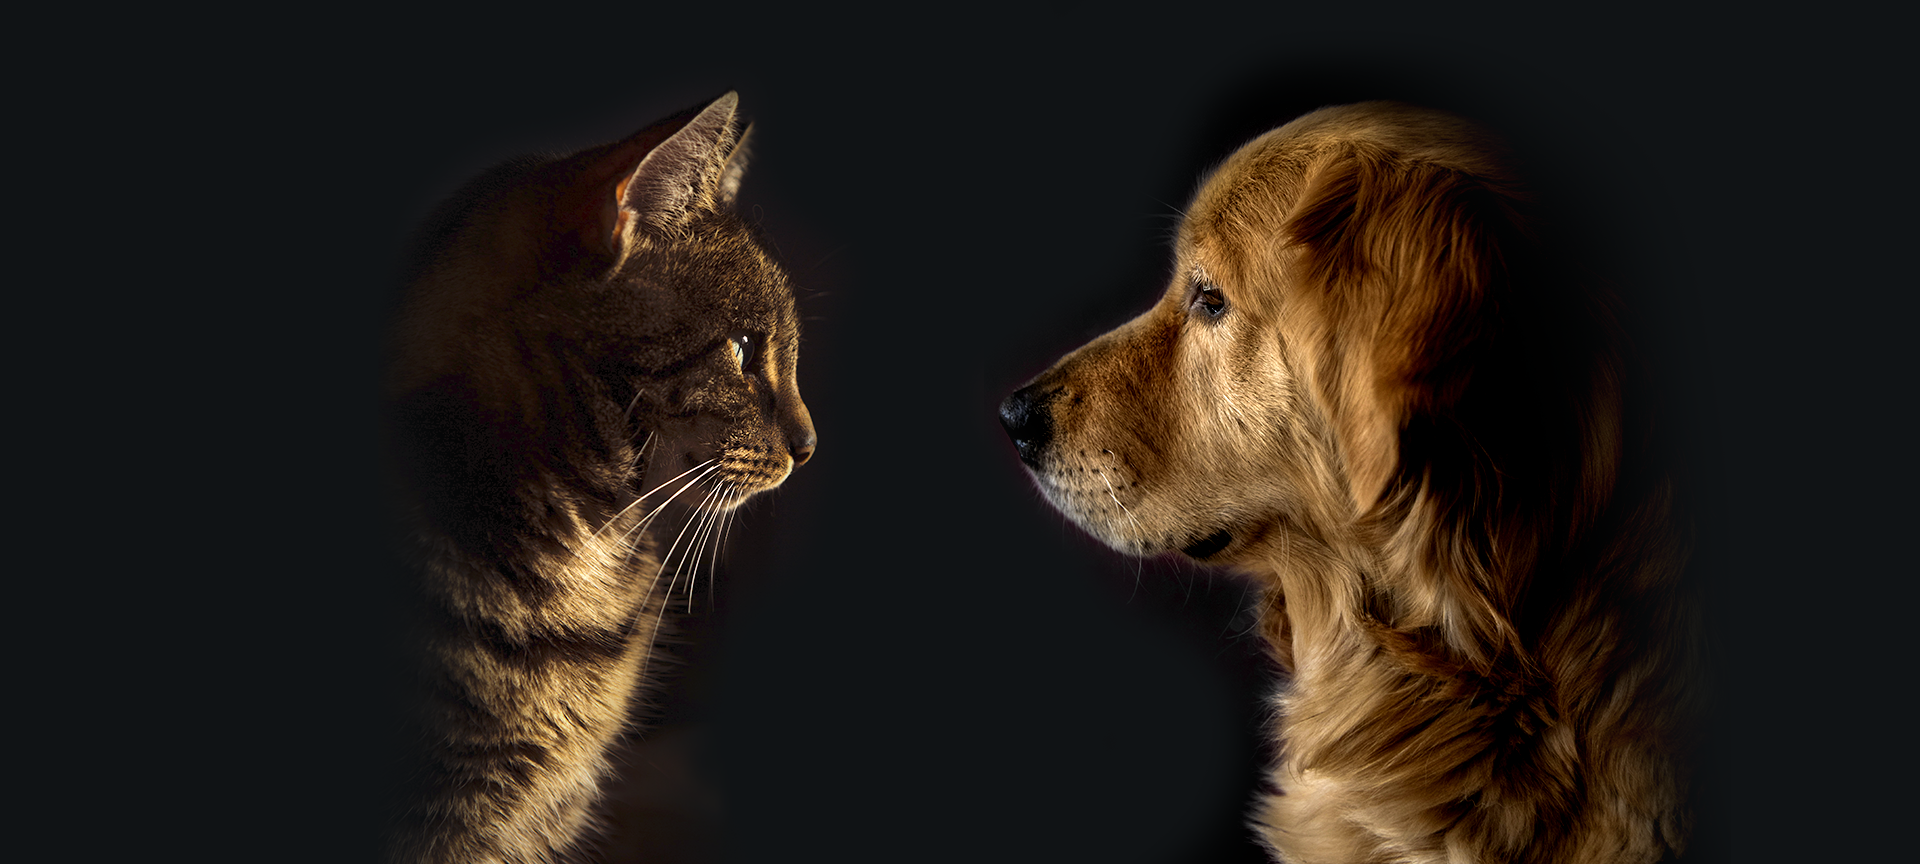

## 1. Install and import dependencies

In [25]:
%pip install ipykernel
%pip install opencv-python
%pip install keras
%pip install scikit-learn
%pip install tensorflow==2.19.0
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load dog and cat images

In [27]:
def load_images(folder):
    images = []
    labels = []
    folder_name = os.path.basename(folder)

    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (224, 224))
            images.append(img)

            if folder_name == 'Dog_reduced':
                labels.append(1)
            elif folder_name == 'Cat_reduced':
                labels.append(0)

    return images, labels

# Load images and labels from both classes
dogs_images, dogs_labels = load_images('/Users/eugenio/Documents/ArtificialIntelligence/Datasets/catsvsdogs/Dog_reduced')
cats_images, cats_labels = load_images('/Users/eugenio/Documents/ArtificialIntelligence/Datasets/catsvsdogs/Cat_reduced')

images = np.array(dogs_images + cats_images)
labels = np.array(dogs_labels + cats_labels)
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [28]:
from keras.utils import to_categorical

# Convert binary labels to one-hot encoded vectors
# 1 -> [0, 1] (Dog)
# 0 -> [1, 0] (Cat)
labels = to_categorical(labels)
labels

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.

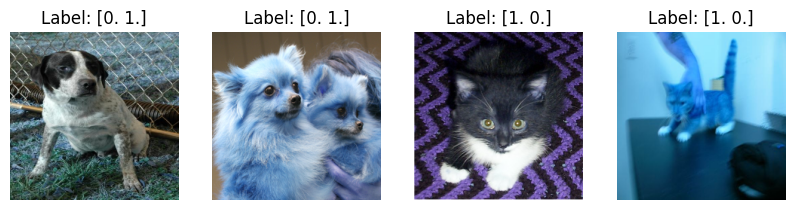

In [30]:
# Show the first 2 and last 2 images with their corresponding categorical labels
plt.figure(figsize=(10, 5))

for i in range(2):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns, position i+1
    plt.imshow(images[i]) # Display the image at index i
    plt.title(f'Label: {labels[i]}')
    plt.axis('off')

for i in range(2):
    plt.subplot(1, 4, i + 3)
    plt.imshow(images[-(i + 1)])
    plt.title(f'Label: {labels[-(i + 1)]}')
    plt.axis('off')

## 3. Split the data into training and test sets

In [31]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2)

## 4. Build and train the VGG16 classifier

In [15]:
# Stop when validation loss no longer improves
early_stopping = EarlyStopping(monitor='val_loss', patience=10) # patience is the number of epochs to wait for improvement before stopping. Improvement is defined as a decrease in the monitored quantity.

# Load VGG16 without its original classifier
baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Add a binary classification head
model = Sequential()
model.add(baseModel)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

# Keep pretrained VGG16 weights fixed (freeze the convolutional base).
for layer in baseModel.layers:
    layer.trainable = False

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, batch_size=32, callbacks=[early_stopping])

loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5674 - loss: 39.3359 - val_accuracy: 0.8906 - val_loss: 6.4321
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9131 - loss: 5.0363 - val_accuracy: 0.9844 - val_loss: 0.8604
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9779 - loss: 1.5929 - val_accuracy: 0.9844 - val_loss: 1.3884
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9953 - loss: 0.2068 - val_accuracy: 0.9375 - val_loss: 3.4038
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9972 - loss: 0.0272 - val_accuracy: 0.9219 - val_loss: 7.5926
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9925 - loss: 0.4411 - val_accuracy: 0.9375 - val_loss: 4.6542
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 3.4851e-04 - val_accuracy: 0.9531 - val_loss: 1.9430
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.9531 - val_loss

## Optional: Save and load the model

In [ ]:
# Save the model in Keras format
model.save('modelo_clasificacion_perros_gatos.keras')

In [22]:
# Load the model from the H5 file
from keras.models import load_model
model = load_model('dogs_vs_cats_classification_model.keras')

## 5. Predict a new image

In [20]:
# Load and resize an unseen image
img = cv2.imread('genaro.jpg')
img = cv2.resize(img, (224, 224))

# Add a batch dimension: (1, 224, 224, 3)
img = np.expand_dims(img, axis=0)

# Predict the class probabilities
pred = model.predict(img)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[1. 0.]]


Keras expects batches, even for one image. Therefore, `pred[0]` contains the two class probabilities:

- `pred[0][0]`: cat
- `pred[0][1]`: dog

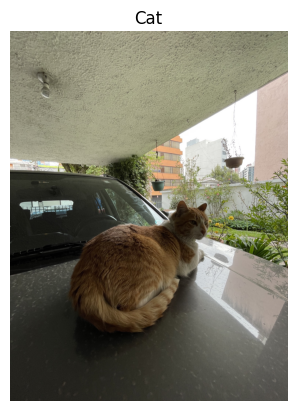

In [24]:
# Display the unseen image in RGB
img = cv2.imread('genaro.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Use the highest predicted probability as the class
# 0 -> [1, 0] (Cat)
# 1 -> [0, 1] (Dog)
if pred[0][0] > pred[0][1]:
    plt.title('Cat')
else:
    plt.title('Dog')

plt.axis('off')
plt.show()

## Individual graded activity

Build and test an image classifier that distinguishes a chosen student's face from background images.

- **Label 1:** student name
- **Label 2:** background (any image without that student's face)

### Tests

1. An unseen photo of the student. Expected label: student name. **(2 points)**
2. An unseen background image. Expected label: background. **(2 points)**
3. An unseen face of a different person. Expected label: background. **(6 points)**

### Optional hyperparameter experiments

Test dataset augmentation, loss function, optimizer, number of epochs, or batch size.

### Presentation

Present the results in class. The grade depends on success in all three tests.